In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#lendo os dados
df = pd.read_csv("../data/WineQT.csv")

In [6]:
#lendo primeiras linhas
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [ ]:
#Numero de linhas e colunas
df.shape

(1143, 13)

In [9]:
#informações do conjunto de dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


# Primeiros achados
Não temos nulos em nenhuma coluna
São 13 colunas sendo uma índice.
Das 12 variáveis, todas estão no formato float com exceção da Quality que é inteiro



In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


# Achados 2
Fixed acidicity: assimetria a direita
volatile acidity: média próximo da mediana, indicando maior simetria
citric acid: maior simetria
residual sugar: maior simetria com outliers próximo ao máximo
chlorides: assimetria a direita
free sulfur dioxide: assimetrico a direita
total sulfur dioxide: bem assimetrico a direita
density: simetrico
pH: simetrico
sulphates: assimetrico a direita
alcohol: levemente assimetrico a direita
quality: assimetrico a esquerda. mediana menor que a média

In [14]:
#sem duplicadas
df.duplicated().sum()

np.int64(0)

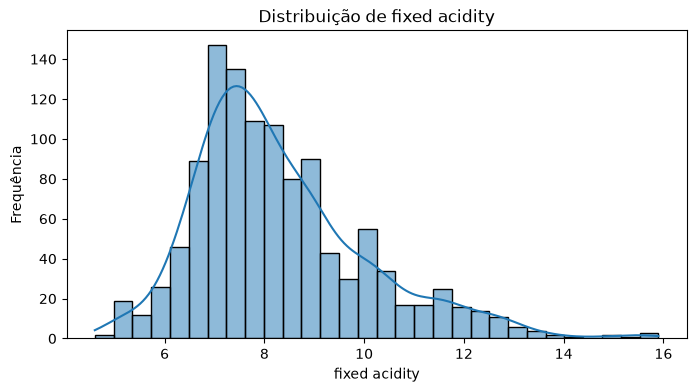

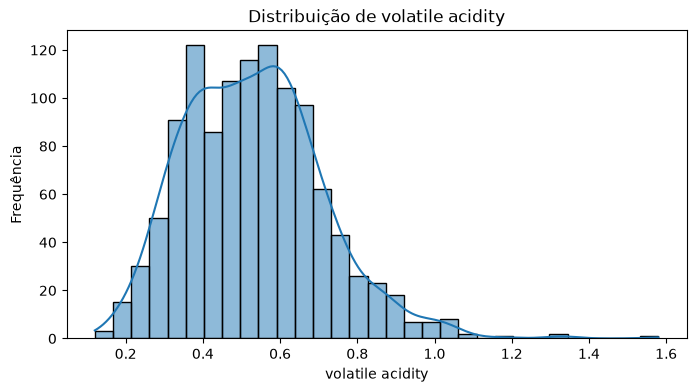

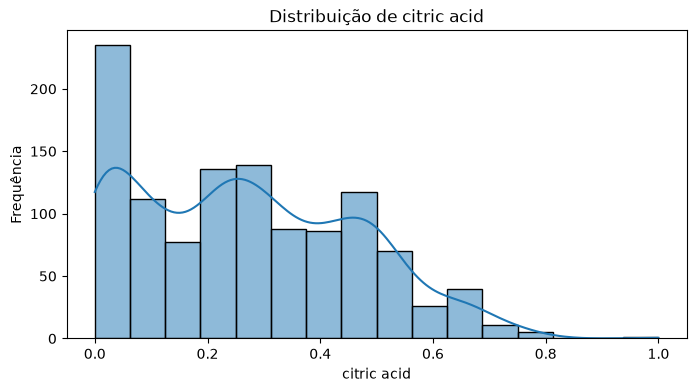

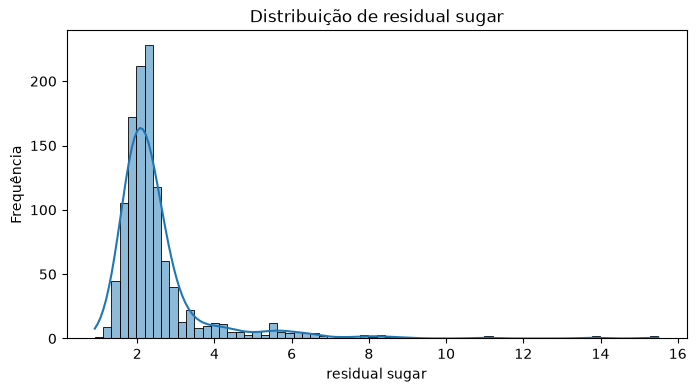

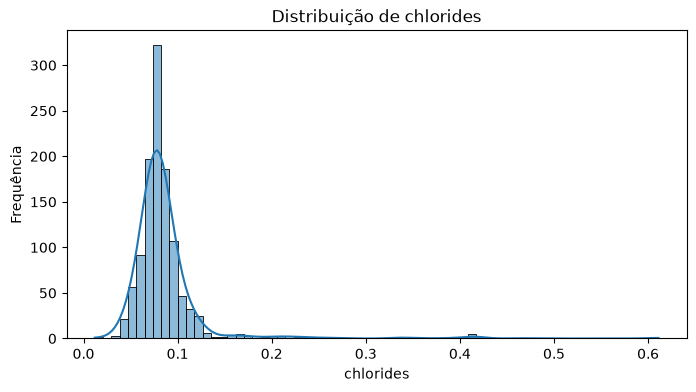

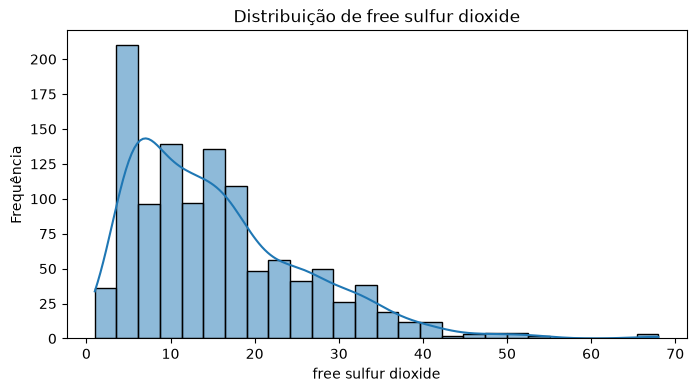

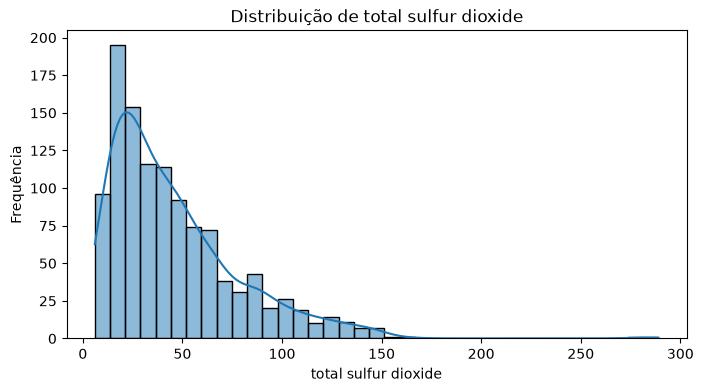

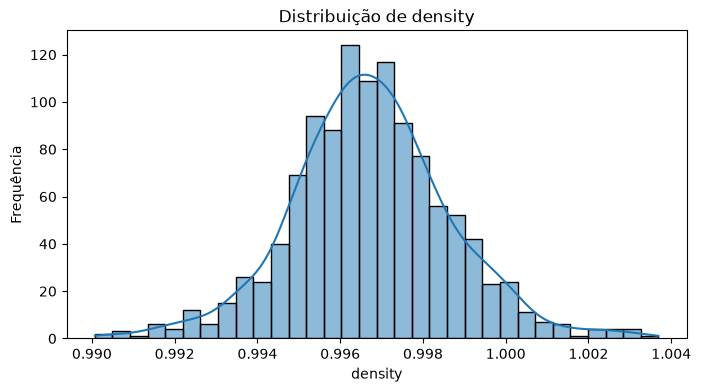

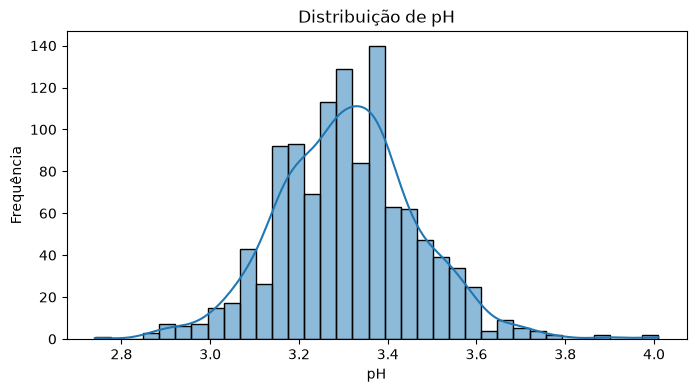

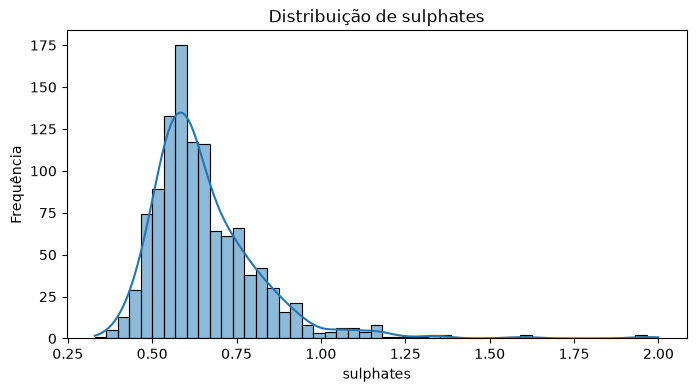

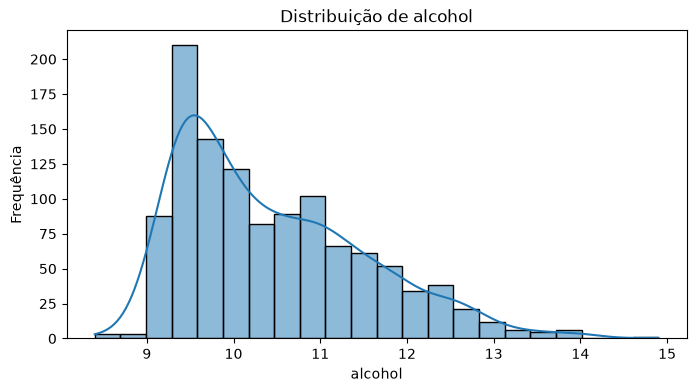

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

for column in features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=column, kde=True)
    plt.title(f"Distribuição de {column}")
    plt.xlabel(column)
    plt.ylabel("Frequência")
    plt.show()

# Achados 3
As variáveis citric acid, free sulfur dioxide, total sulfur, e alcohol são as que menos parecem uma distribuição normal na primeira vista. em geral se concentra nos valores menores e vão decaindo em volume a medida que a escala aumenta de valor

As variáveis com mais valores extremos parecem ser sulphates, free sulfur dioxide, total sulfur, clorides e residual sugar.




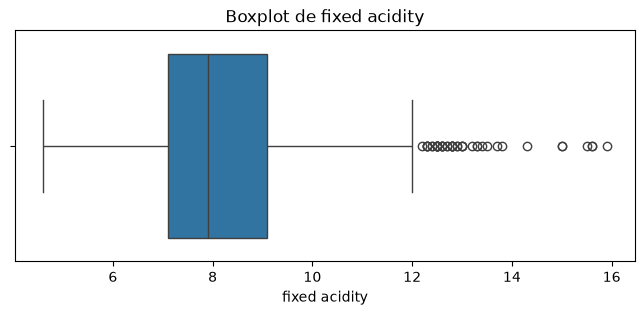

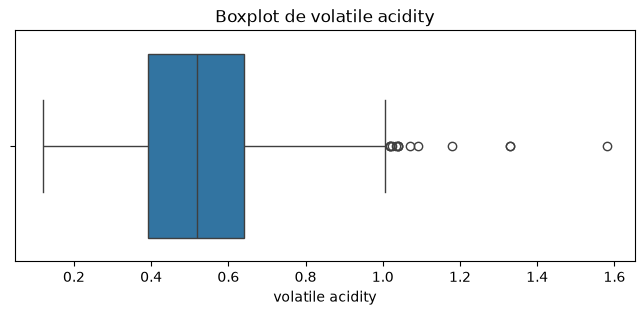

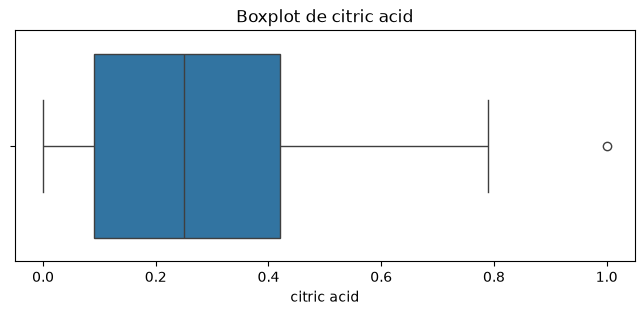

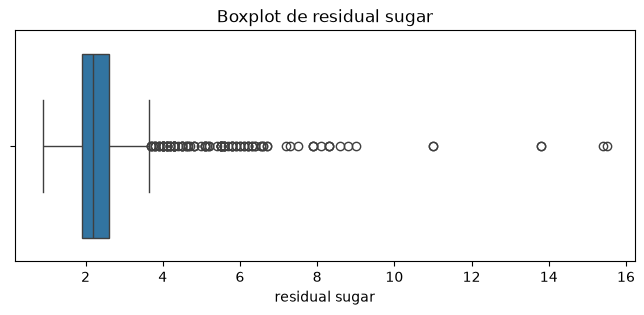

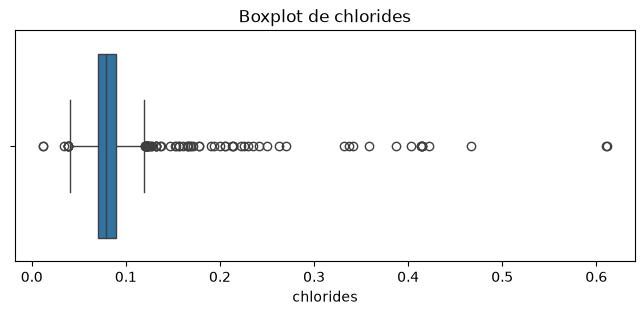

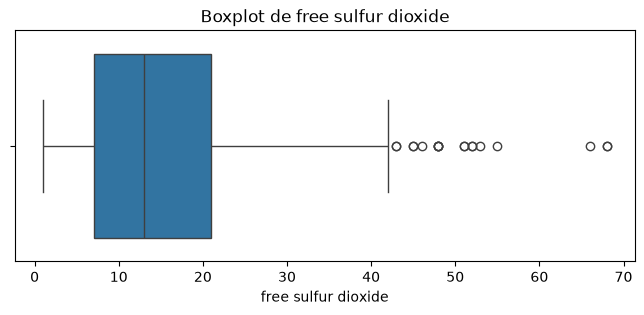

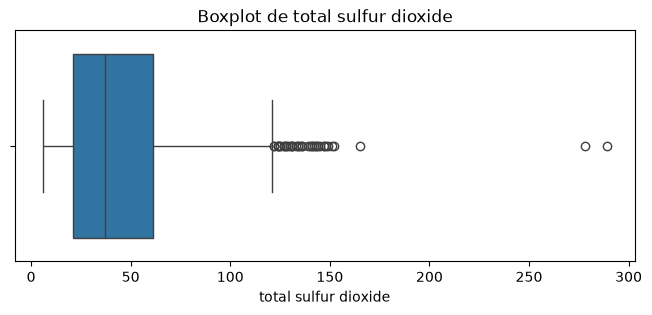

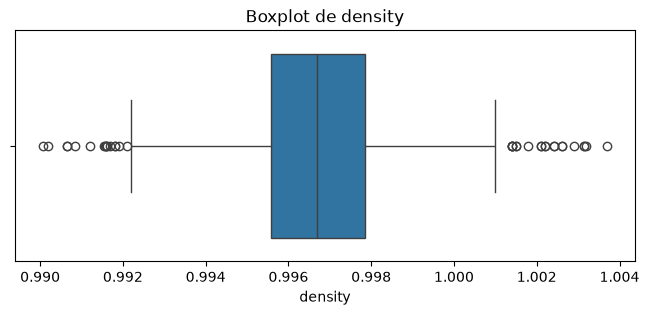

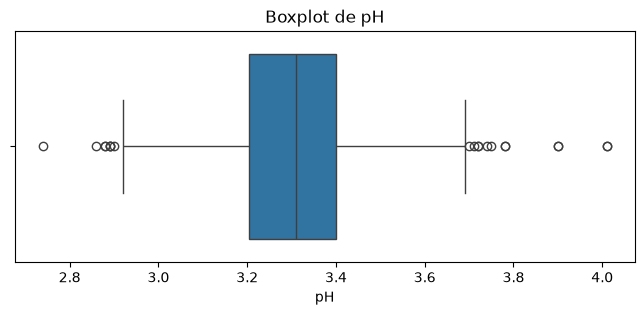

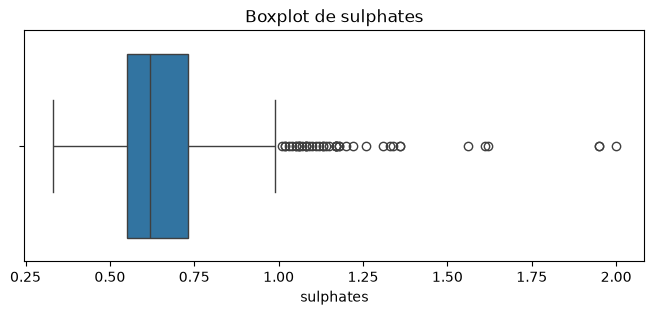

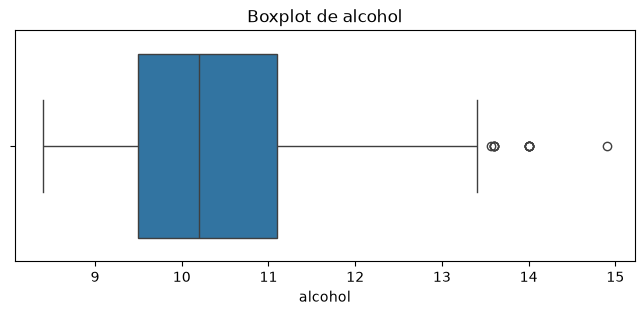

In [18]:
for column in features:
    plt.figure(figsize=(8, 3))
    sns.boxplot(data=df, x=column)
    plt.title(f"Boxplot de {column}")
    plt.xlabel(column)
    plt.show()

# Análise da nossa variável alvo, quality

In [ ]:
#contagem da quantidade de vezes que aparece os valores
df["quality"].value_counts().sort_index()

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

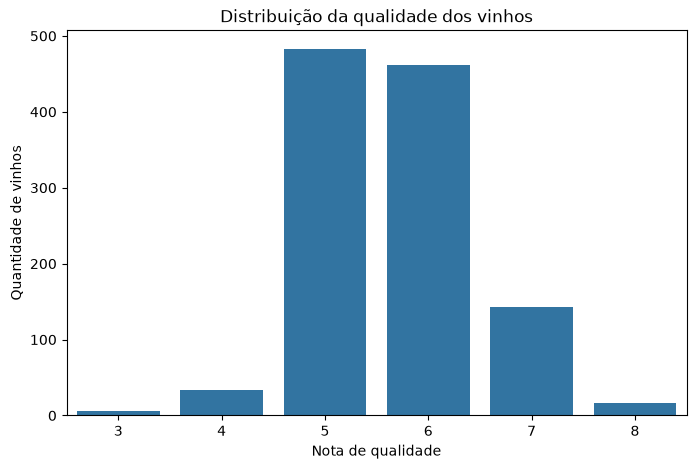

In [22]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="quality",
    order=sorted(df["quality"].unique())
)

plt.title("Distribuição da qualidade dos vinhos")
plt.xlabel("Nota de qualidade")
plt.ylabel("Quantidade de vinhos")
plt.show()

# Achados 4

Nossa variável alvo, através do gráfico, mostrou uma forte concentração em 2 notas> 5 e 6

Existem poucas observações nas notas extremas

Ainda sim vemos mais observações nos valores acima da média do que abaixo

# Criando a variável quality_class

Afim de criar uma variável binária, analisando a concentração das notas, vou criar 2 cenários:

- Se o corte for 7, então um grupo >= 7 e outro <7:
    teremos um desbalanceamento condiserando que acima de 7 seria um grupo de aproximadamente 14% e o outro de 86%
- Se o corte for 6, então um grupo >= 6 e outro <6:
    O balanceamento seria aproximadamente 46% abaixo de 6 e 54% acima

O primerio cenário, conceitualmente nos trás categorias melhores para definir um vinho de "Alta qualidade". Porém um desbalanceamento nos dados pode levar a uma acurácia aparentemente alta por favorecer a classe majoritária.

O segundo cenário categoriza em grupos de tamanho similar, porém conceitualmente chamar um vinho de nota 6 de "Alta qualidade" pode ser questionável.

Adim de decidir o melhor cenário, será criado as duas variáveis para testarmos posteriormente.

In [ ]:
#criando categorias com corte 7

df["quality_class_7"] = np.where(
    df["quality"] >= 7,
    "Alta Qualidade",
    "Baixa/Média Qualidade"
)

In [25]:
#criando categorias com corte 6

df["quality_class_6"] = np.where(
    df["quality"] >= 6,
    "Alta Qualidade",
    "Baixa/Média Qualidade"
)

In [26]:
print("Corte em 7:")
print(df["quality_class_7"].value_counts())
print(df["quality_class_7"].value_counts(normalize=True) * 100)

print("\nCorte em 6:")
print(df["quality_class_6"].value_counts())
print(df["quality_class_6"].value_counts(normalize=True) * 100)

Corte em 7:
quality_class_7
Baixa/Média Qualidade    984
Alta Qualidade           159
Name: count, dtype: int64
quality_class_7
Baixa/Média Qualidade    86.089239
Alta Qualidade           13.910761
Name: proportion, dtype: float64

Corte em 6:
quality_class_6
Alta Qualidade           621
Baixa/Média Qualidade    522
Name: count, dtype: int64
quality_class_6
Alta Qualidade           54.330709
Baixa/Média Qualidade    45.669291
Name: proportion, dtype: float64



#Decidindo o corte

A distribuição original da qualidade é fortemente concentrada nas notas 5 e 6. Ao aplicar o corte de 7 pontos, apenas aproximadamente 14% das amostras são classificadas como alta qualidade, gerando um cenário de desbalanceamento relevante para a modelagem.

Embora o corte em 6 produza classes mais equilibradas, optamos por manter o corte em 7 por representar uma definição mais conservadora de alta qualidade e por estar alinhado à regra sugerida no enunciado. O desbalanceamento será considerado na escolha das métricas e na avaliação dos modelos.

In [ ]:
#criando a categoria

df["quality_class"] = np.where(
    df["quality"] >= 7,
    "Alta Qualidade",
    "Baixa/Média Qualidade"
)

In [ ]:
df[["quality", "quality_class"]].head(10)

,quality,quality_class
0,5,Baixa/Média Qualidade
1,5,Baixa/Média Qualidade
2,5,Baixa/Média Qualidade
3,6,Baixa/Média Qualidade
4,5,Baixa/Média Qualidade
5,5,Baixa/Média Qualidade
6,5,Baixa/Média Qualidade
7,7,Alta Qualidade
8,7,Alta Qualidade
9,5,Baixa/Média Qualidade


# Balanceamento das classes

In [ ]:
#contando as classes

df["quality_class"].value_counts()

quality_class
Baixa/Média Qualidade    984
Alta Qualidade           159
Name: count, dtype: int64

In [ ]:
#analisando a proporção

df["quality_class"].value_counts(normalize=True) * 100

quality_class
Baixa/Média Qualidade    86.089239
Alta Qualidade           13.910761
Name: proportion, dtype: float64

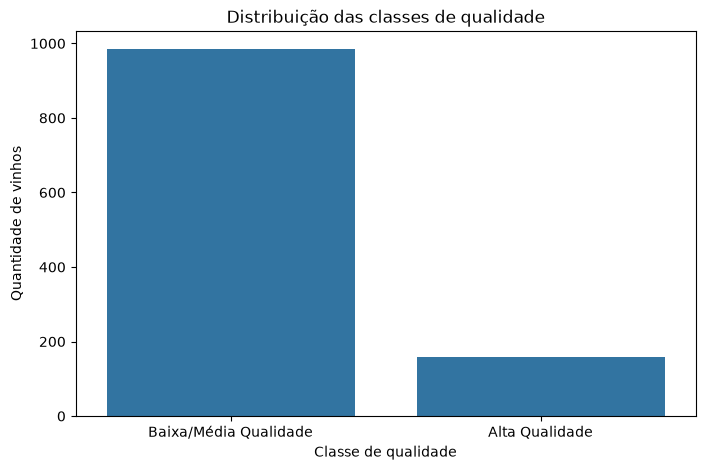

In [34]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="quality_class"
)

plt.title("Distribuição das classes de qualidade")
plt.xlabel("Classe de qualidade")
plt.ylabel("Quantidade de vinhos")
plt.show()

# Identificando outliers

In [36]:
outlier_summary = []

for column in features:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        "Variável": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Limite inferior": lower_bound,
        "Limite superior": upper_bound,
        "Qtd. outliers": len(outliers),
        "% outliers": len(outliers) / len(df) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    "% outliers",
    ascending=False
)

,Variável,Q1,Q3,IQR,Limite inferior,Limite superior,Qtd. outliers,% outliers
3,residual sugar,1.90000,2.600000,0.700000,0.850000,3.650000,110,9.623797
4,chlorides,0.07000,0.090000,0.020000,0.040000,0.120000,77,6.736658
0,fixed acidity,7.10000,9.100000,2.000000,4.100000,12.100000,44,3.849519
9,sulphates,0.55000,0.730000,0.180000,0.280000,1.000000,43,3.762030
6,total sulfur dioxide,21.00000,61.000000,40.000000,-39.000000,121.000000,40,3.499563
7,density,0.99557,0.997845,0.002275,0.992157,1.001257,36,3.149606
8,pH,3.20500,3.400000,0.195000,2.912500,3.692500,20,1.749781
5,free sulfur dioxide,7.00000,21.000000,14.000000,-14.000000,42.000000,18,1.574803
1,volatile acidity,0.39250,0.640000,0.247500,0.021250,1.011250,14,1.224847
10,alcohol,9.50000,11.100000,1.600000,7.100000,13.500000,12,1.049869


# Achados 4

Residual sugar é a variável com mais outliers, chegando a 9,6% seguido de chlorides com 6,7%

Esses registros serão posteriormente avaliados durante o pré-processamento para determinar se representam observações válidas ou inconsistências.


## Teste de alteração